# End-to-End Data Science Capstone: Netflix Catalogue Timing

**Yuva Internship — Week 6**  
**Student:** Vikhyath Bharadwaj K S  
**Dataset:** Netflix Movies and TV Shows (Kaggle snapshot)  
**Submission date:** 3 October 2026

This project examines the approximate gap between a title’s release year and the year the catalogue snapshot says it was added. It combines data quality review, exploratory analysis, a leakage-aware regression workflow, and evidence-based interpretation. The dataset does not record licensing decisions, viewing behavior, or causal drivers.

## 1. Problem statement
Netflix catalogue metadata records a release year and an addition date for most titles. Can title metadata estimate their difference? The target is a descriptive proxy, `year(date_added) - release_year`, in whole years. This is not a direct measure of licensing lead time.

## 2. Objectives and analytical questions
- How complete and internally consistent are the fields needed to calculate this proxy?
- How does the proxy vary across time and common genres?
- Do simple metadata features estimate the proxy better than a median baseline?
- What limitations prevent interpreting the model as causal or operational advice?

## 3. Dataset source and description
The repository snapshot is `dataset/original/netflix_titles.csv`, attributed to Shivam Bansal and distributed through Kaggle. Source: [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows). Access checked 3 October 2026. The file contains catalogue metadata, not user-level or licensing records. Dataset page terms should be checked before redistribution; the repository retains the already-present file.

## 4. Libraries and reproducibility

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if not (ROOT / "src" / "capstone_pipeline.py").exists():
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from capstone_pipeline import run_pipeline
import pandas as pd
import matplotlib.pyplot as plt
SEED = 42
print("Project root:", ROOT)
print("Random seed:", SEED)

Project root: C:\Users\vikhy\OneDrive\Documents\Desktop\yuva-intern\yuva-intern-week1-netflix
Random seed: 42


## 5. Dataset acquisition and loading
The raw snapshot is loaded locally so the notebook runs without a network request and preserves the original source file. The pipeline writes derived outputs under `dataset/processed/` and figures under `visualizations/week6/`.

In [2]:
raw = pd.read_csv(ROOT / "dataset" / "original" / "netflix_titles.csv")
print("Shape:", raw.shape)
display(raw.head())

Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, Rodolfo Valente, Vaneza Oliveira, Rafael Lozano, Viviane Porto, Mel Fronckowiak, Sergio Mamberti, Zezé Motta, Celso Frateschi",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi & Fantasy","In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor."
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, Azalia Ortiz, Octavio Michel, Carmen Beato",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies","After a devastating earthquake hits Mexico City, trapped survivors from all walks of life wait to be rescued while trying desperately to stay alive."
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence Koh, Tommy Kuan, Josh Lai, Mark Lee, Susan Leong, Benjamin Lim",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly, Christopher Plummer, Crispin Glover, Martin Landau, Fred Tatasciore, Alan Oppenheimer, Tom Kane",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi & Fantasy","In a postapocalyptic world, rag-doll robots hide in fear from dangerous machines out to exterminate them, until a brave newcomer joins the group."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aaron Yoo, Liza Lapira, Jacob Pitts, Laurence Fishburne, Jack McGee, Josh Gad, Sam Golzari, Helen Carey, Jack Gilpin",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-counting experts with the intent of swindling millions out of Las Vegas casinos by playing blackjack.


## 6. Initial inspection and data quality
We inspect field types, missingness, duplicates, and invalid target values before modeling. A title lacking `date_added` cannot have a measured delay. Negative gaps are treated as invalid for this proxy; they are counted and excluded from the modeling subset, without changing the raw file. Extreme nonnegative values remain.

In [3]:
display(raw.dtypes.to_frame("dtype"))
display(raw.isna().sum().rename("missing").to_frame())
print("Exact duplicate rows:", raw.duplicated().sum())

Exact duplicate rows: 0


,dtype
show_id,str
type,str
title,str
director,str
cast,str
country,str
date_added,str
release_year,int64
rating,str
duration,str


,missing
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


## 7. Cleaning and analytical population
Parsing is coercive and non-destructive. The analysis population requires a parseable addition date and release year and a nonnegative difference. Missing categorical predictors are imputed inside the training pipeline. No valid high-delay observation is deleted as an outlier.

## 8. Exploratory data analysis
The charts describe this snapshot. Addition counts can reflect the dataset’s coverage and collection period. Genre-level distributions are observational and may differ because of catalogue composition.

## 9. Feature engineering
The outcome uses two year fields, `year_added - release_year`. To avoid direct arithmetic leakage, neither year is included as a predictor. Inputs are type, rating, first listed genre, first listed country, genre and country counts, and the numeric duration value. First-listed values are order-dependent metadata summaries, not complete genre/country profiles.

## 10. Modeling methodology
A median DummyRegressor is the baseline. Ridge, Random Forest, and histogram gradient boosting provide candidate regressors. Numeric fields use median imputation and standardization; categorical fields use most-frequent imputation and one-hot encoding with rare categories grouped. Preprocessing is fit separately within each cross-validation fold and training split.

## 11. Training, validation, and tuning
An 80/20 random split (seed 42) reserves the test set. Five-fold shuffled K-fold cross-validation compares candidates on training data. Fixed, documented configurations limit compute; this is comparative model selection, not an exhaustive hyperparameter search. The test set is used once for the selected model’s final metrics.

## 12. Execute the complete pipeline

In [4]:
metrics, quality, comparison = run_pipeline()
print(json.dumps({k: metrics[k] for k in ["analysis_rows", "selected_model", "test_mae", "test_rmse", "test_r2"]}, indent=2))
display(comparison.round(3))
display(pd.Series(quality["delay_describe"], name="delay_years").to_frame())

{
  "analysis_rows": 7677,
  "selected_model": "Random forest",
  "test_mae": 3.7594999359271597,
  "test_rmse": 6.735542089687107,
  "test_r2": 0.35693942599058537
}


,model,cv_mae_mean,cv_mae_sd,cv_rmse_mean,cv_r2_mean,test_mae,test_rmse,test_r2
0,Random forest,3.807,0.132,6.685,0.424,3.759,6.736,0.357
1,Histogram gradient boosting,3.889,0.105,6.714,0.419,3.835,6.817,0.341
2,Ridge regression,4.152,0.154,6.957,0.376,4.081,7.099,0.286
3,Median baseline,4.321,0.174,9.512,-0.166,4.210,9.103,-0.175


,delay_years
count,7677.00000
mean,4.56780
std,8.74002
min,0.00000
25%,0.00000
50%,1.00000
75%,5.00000
90%,13.00000
95%,21.00000
max,93.00000


## 13. EDA and model visualizations
The following figures are generated by the source pipeline and saved for the report and README.

delay_distribution.png
delay_by_genre.png
additions_by_year.png
model_comparison.png
observed_vs_estimated.png


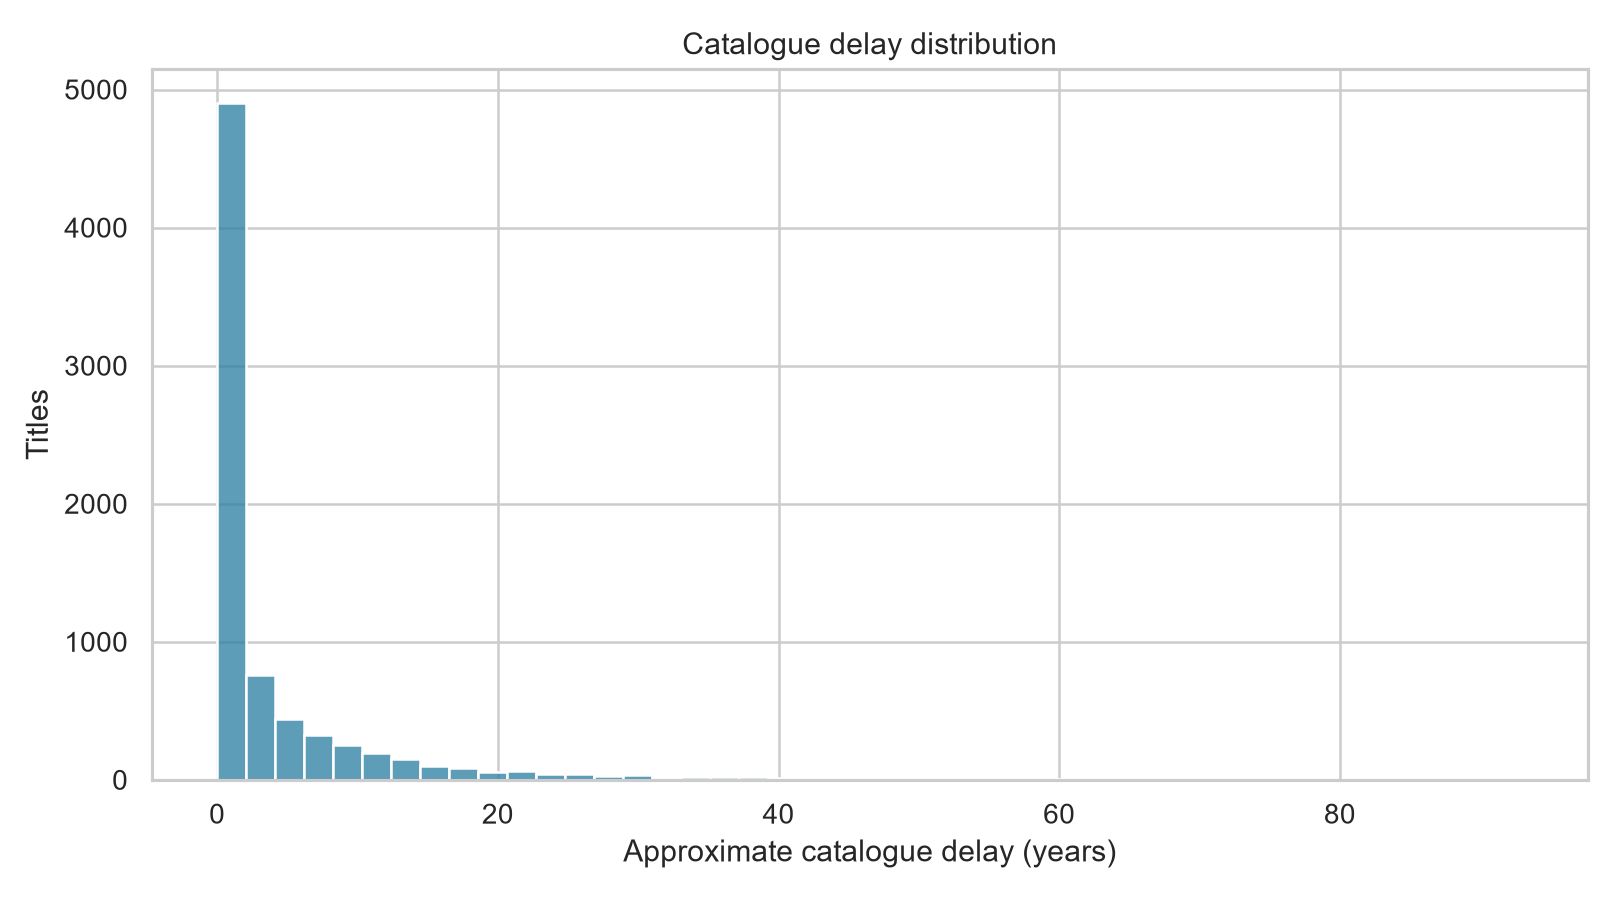

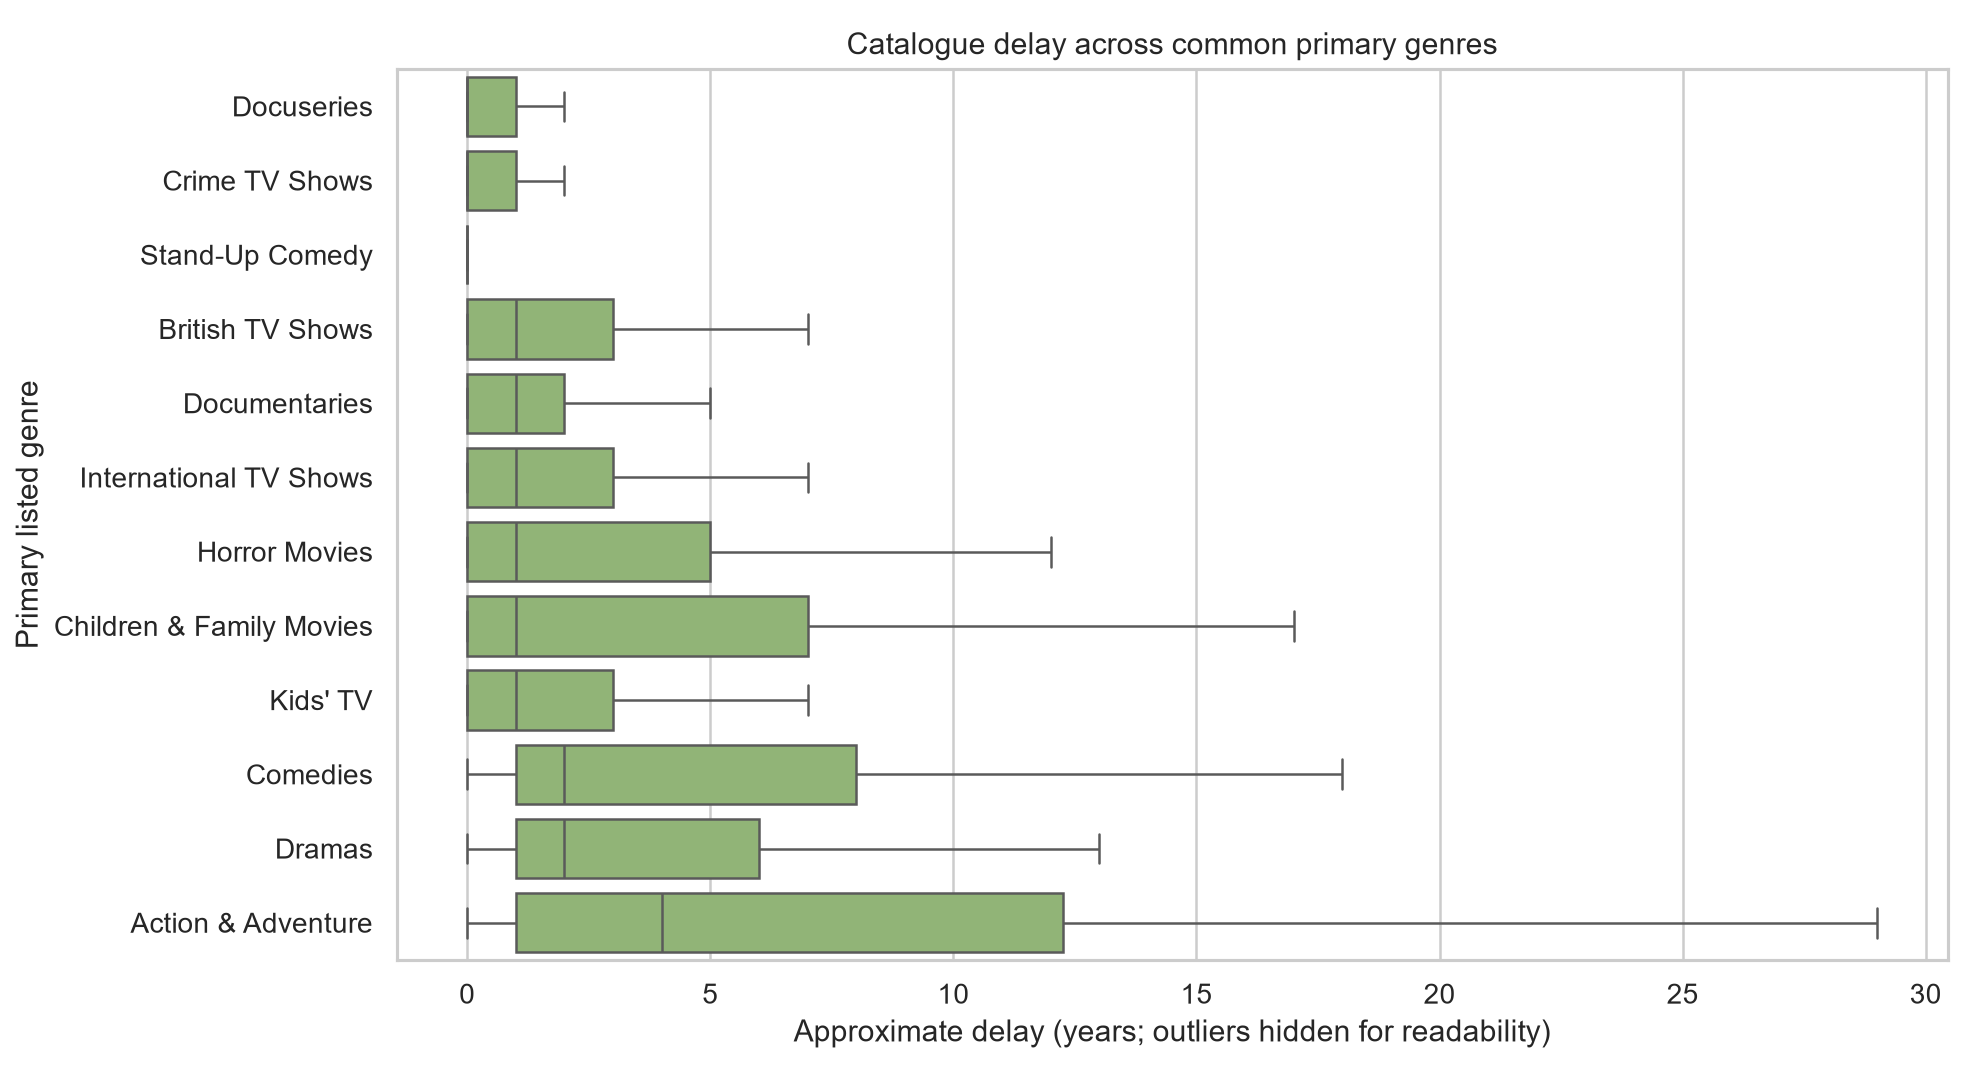

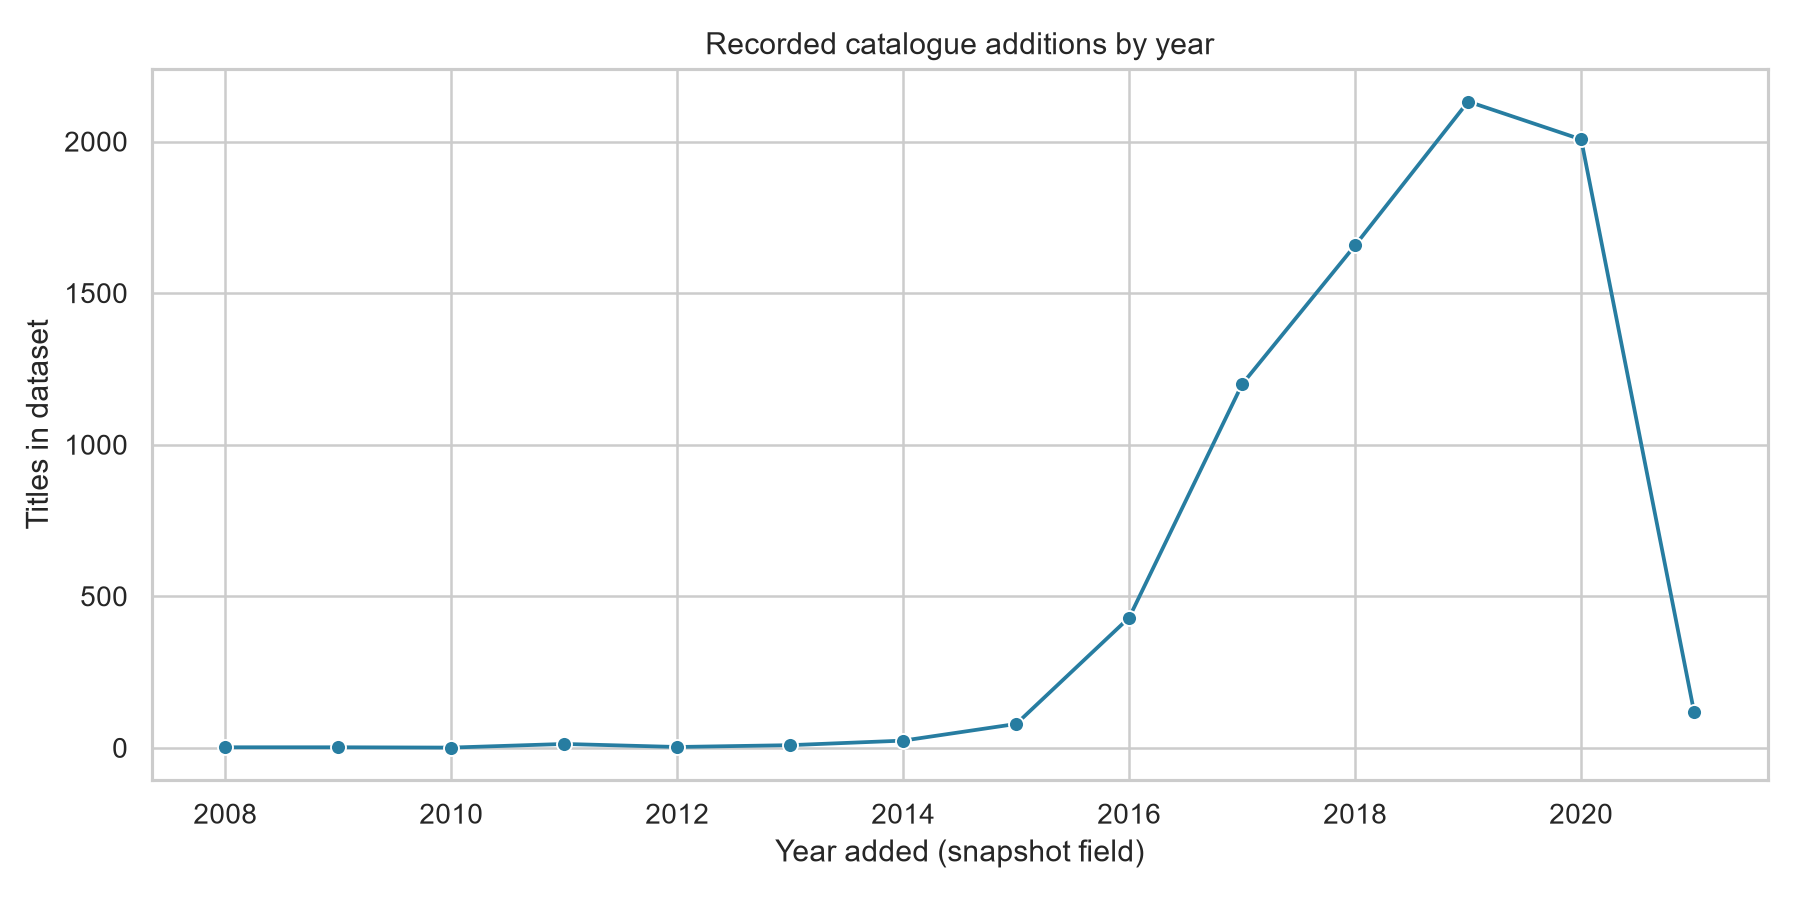

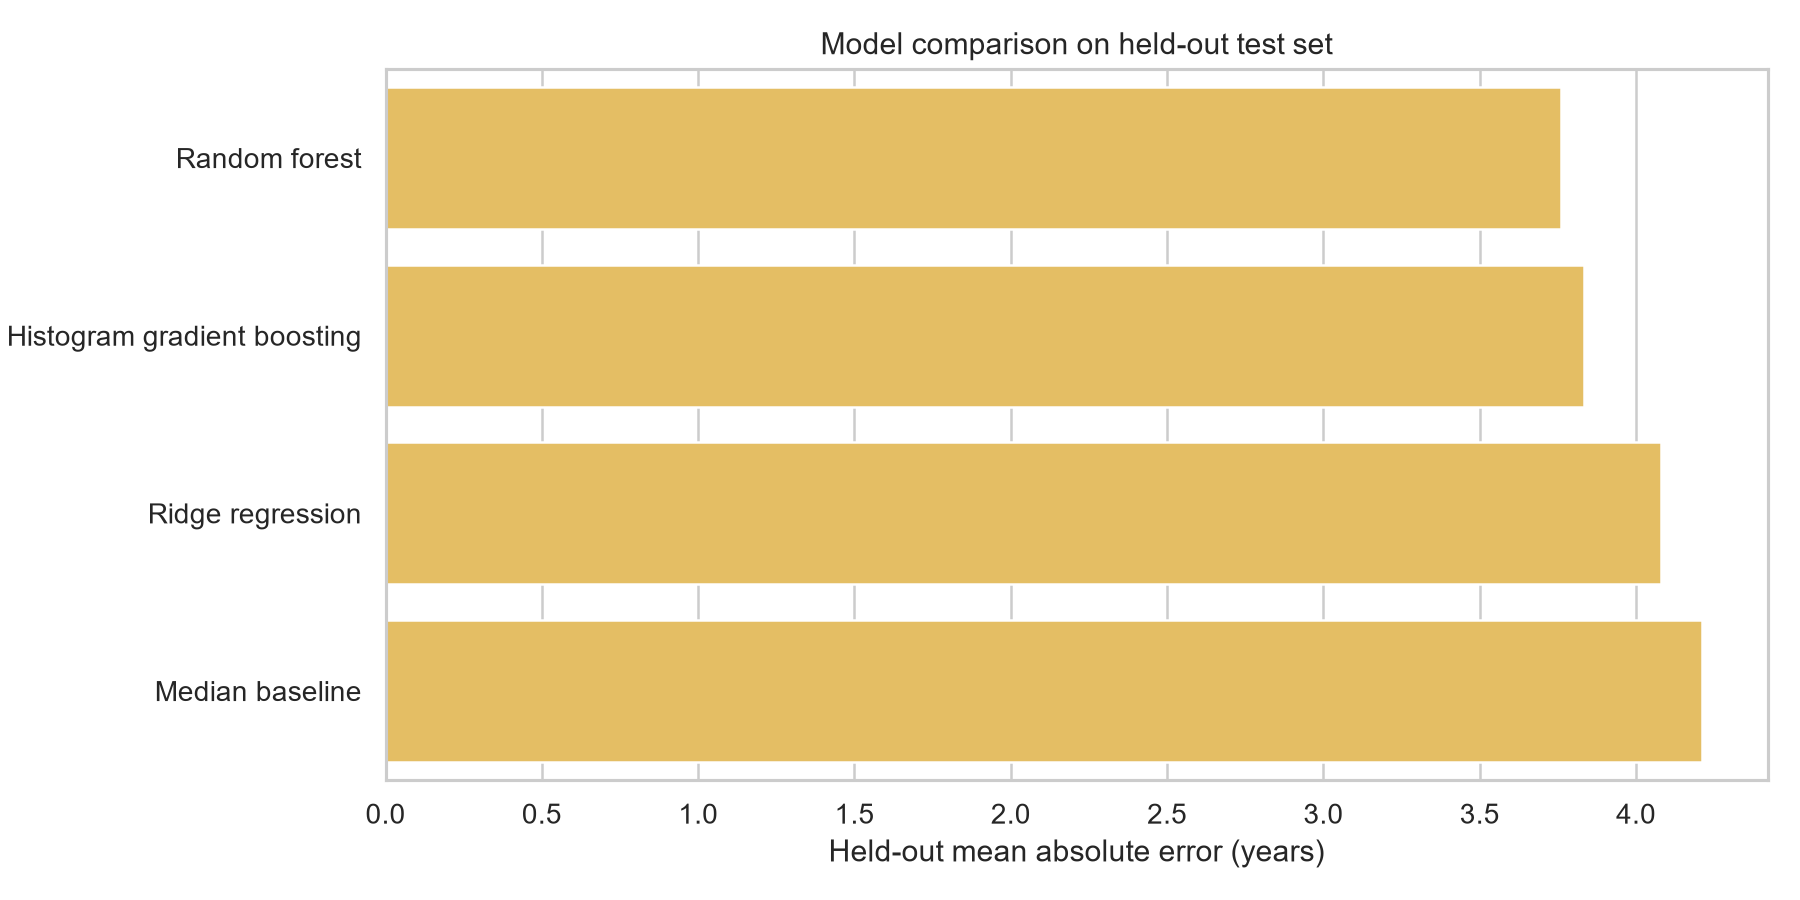

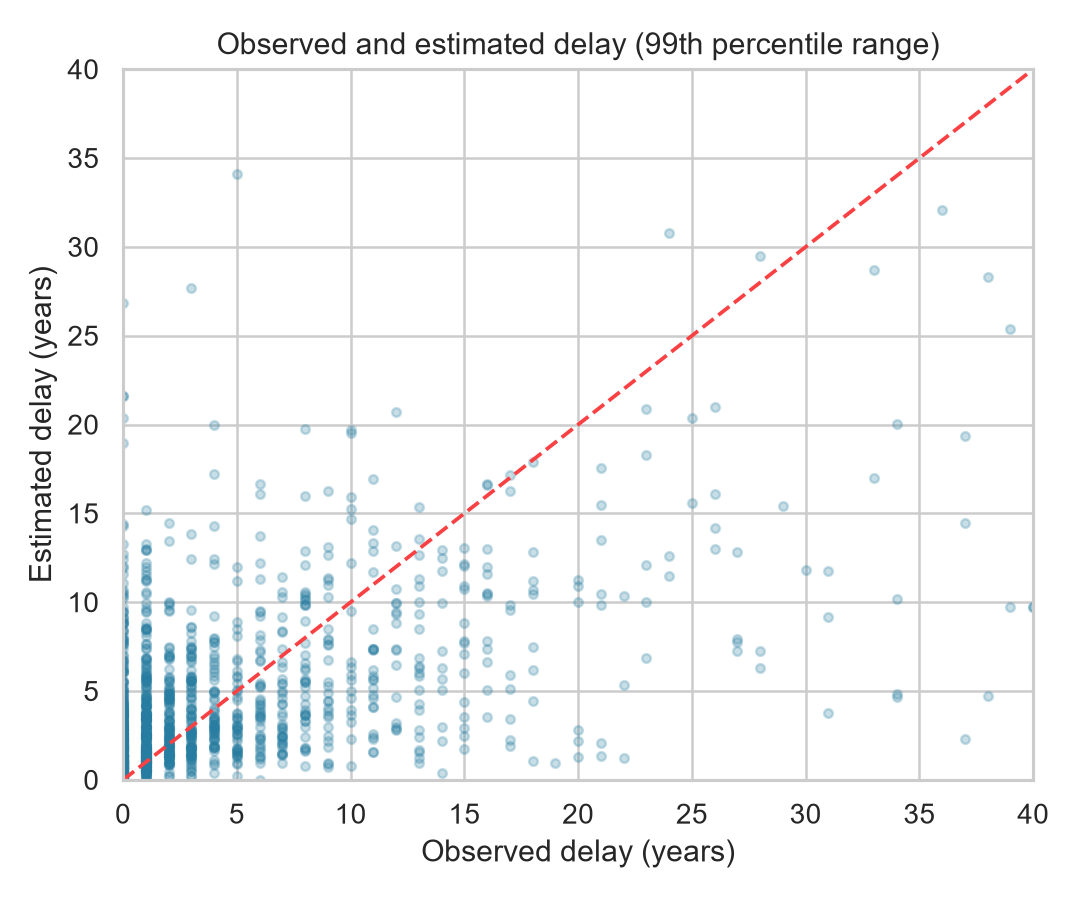

In [5]:
from IPython.display import Image
for name in ["delay_distribution.png", "delay_by_genre.png", "additions_by_year.png", "model_comparison.png", "observed_vs_estimated.png"]:
    print(name)
    display(Image(filename=str(ROOT / "visualizations" / "week6" / name), width=720))

## 14. Model evaluation and interpretation
MAE is the primary metric because it expresses a typical absolute error in years and is less sensitive to the long upper tail than RMSE. RMSE penalizes large errors more heavily. R-squared compares prediction error with the mean-target baseline but does not establish practical usefulness. The notebook reports only measured results from the executed split.

In [6]:
print(f"Selected model: {metrics['selected_model']}")
print(f"Test MAE: {metrics['test_mae']:.2f} years")
print(f"Test RMSE: {metrics['test_rmse']:.2f} years")
print(f"Test R-squared: {metrics['test_r2']:.3f}")
print(f"Test support: {metrics['test_rows']}")

Selected model: Random forest
Test MAE: 3.76 years
Test RMSE: 6.74 years
Test R-squared: 0.357
Test support: 1536


## 15. Findings and recommendations
Direct observations include the delay distribution, genre differences, and model error. Recommendations are limited to exploratory use: catalogue operators would need current, representative data and actual acquisition decision labels before using such estimates. Do not use the model to infer licensing terms, audience demand, or causal effects.

## 16. Challenges and limitations
The 98 missing addition dates and source inconsistencies constrain the analytical population. Calendar-year subtraction is coarse and ignores exact dates. The snapshot is observational and may have selection and time-period bias. First-listed categories compress multi-valued metadata. The random holdout does not test later years; time-based validation would better measure prospective generalization. The selected forest leaves considerable unexplained variation, and associations are not causes.

## 17. Future scope
Use a dated, regularly collected catalogue panel; compare time-based and group-based validation; enrich with independently documented acquisition dates if licensed; assess errors across subgroups; examine prediction intervals; and test whether richer multi-hot categories improve held-out performance.

## 18. Conclusion
This capstone reuses the Netflix project coherently by asking a distinct catalogue-timing question. The workflow audits source data, engineers a transparent approximate target, compares leakage-aware regression models, evaluates on held-out data, and reports limits alongside results. It demonstrates an end-to-end pipeline without claiming a causal or business outcome.

## 19. References
1. Bansal, S. Netflix Movies and TV Shows. Kaggle dataset page: https://www.kaggle.com/datasets/shivamb/netflix-shows (accessed 3 October 2026).
2. scikit-learn user guide: https://scikit-learn.org/stable/user_guide.html
3. pandas documentation: https://pandas.pydata.org/docs/
4. Matplotlib documentation: https://matplotlib.org/stable/
5. Seaborn documentation: https://seaborn.pydata.org/